# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import numpy as np
import matplotlib.pyplot as plt

## 1. Preprocessing

In [2]:
df = pd.read_csv('../data/checker_submits.csv', parse_dates=['timestamp'])
df.head()

,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104


In [3]:
df['hour'] = df.timestamp.dt.hour
df['dayofweek'] = df.timestamp.dt.day_of_week
df.drop(columns='timestamp', inplace=True)
df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [4]:
df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [5]:
categorical_columns = ['uid', 'labname']
for col in categorical_columns:
    enc = OneHotEncoder(sparse_output=False)
    enc.fit(df[[col]])
    res = enc.transform(df[[col]])
    new_columns = enc.categories_[0]
    new_columns = [f'{col}_{new_col}' for new_col in new_columns]
    df[new_columns] = res
df.drop(columns=categorical_columns, inplace=True)

In [6]:
continious_features = ['numTrials',	'hour']
df[continious_features] = StandardScaler().fit_transform(df[continious_features])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   numTrials         1686 non-null   float64
 1   hour              1686 non-null   float64
 2   dayofweek         1686 non-null   int32  
 3   uid_user_0        1686 non-null   float64
 4   uid_user_1        1686 non-null   float64
 5   uid_user_10       1686 non-null   float64
 6   uid_user_11       1686 non-null   float64
 7   uid_user_12       1686 non-null   float64
 8   uid_user_13       1686 non-null   float64
 9   uid_user_14       1686 non-null   float64
 10  uid_user_15       1686 non-null   float64
 11  uid_user_16       1686 non-null   float64
 12  uid_user_17       1686 non-null   float64
 13  uid_user_18       1686 non-null   float64
 14  uid_user_19       1686 non-null   float64
 15  uid_user_2        1686 non-null   float64
 16  uid_user_20       1686 non-null   float64


In [7]:
df.to_csv('../data/dayofweek.csv', index=False)

In [8]:
X = df.drop(columns='dayofweek')
y = df.dayofweek

In [9]:
y.value_counts().argmax()

np.int64(0)

In [10]:
most_common_day = y.value_counts().idxmax()
naive_accuracy = y.eq(most_common_day).mean()
naive_accuracy

np.float64(0.23487544483985764)

## 2. Algorithms

### a. Logreg

In [11]:
logreg_clf = LogisticRegression(random_state=21, fit_intercept=False)
logreg_clf.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",21
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [12]:
logreg_accuracy = logreg_clf.score(X, y)
logreg_accuracy

0.6405693950177936

In [13]:
def plot_feature_importances(coef, feature_names, top):
    # sum_coefs = np.abs(coef).sum(axis=0)
    feature_importances = pd.DataFrame(data={'feature_name': feature_names, 'importance': coef})
    feature_importances.sort_values('importance', ascending=False, inplace=True)

    fig, ax = plt.subplots()
    feature_importances.head(top).plot.barh(x='feature_name', y='importance', ax=ax, legend=False)
    ax.invert_yaxis()
    ax.set_xlabel('feature importance')
    ax.set_ylabel('feature name')
    plt.show()

In [14]:
def calc_sum_coef(coef):
    return np.abs(coef).sum(axis=0)

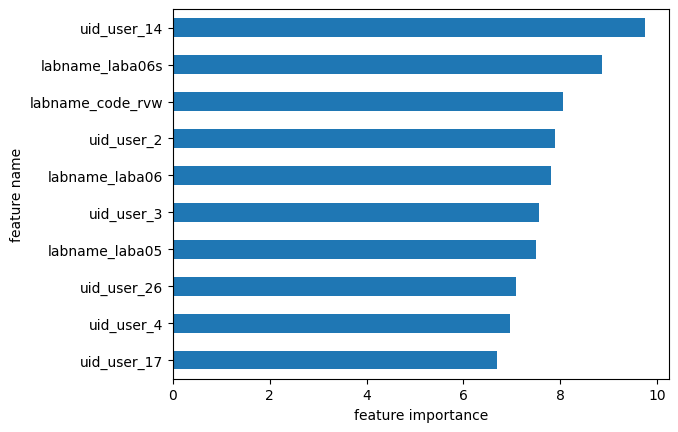

In [15]:
coef = calc_sum_coef(logreg_clf.coef_)
plot_feature_importances(coef=coef, feature_names=X.columns, top=10)

### b. SVC

In [16]:
svc_clf = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21, decision_function_shape='ovr'))
svc_clf.fit(X, y)
svc_accuracy = svc_clf.score(X, y)
svc_accuracy

0.6115065243179122

In [17]:
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    clf = SVC(probability=True, random_state=21, kernel=kernel)
    clf.fit(X, y)
    accuracy = clf.score(X, y)
    print(f"kernel : '{kernel}', accuracy: {accuracy}")

kernel : 'linear', accuracy: 0.702846975088968
kernel : 'poly', accuracy: 0.8594306049822064
kernel : 'rbf', accuracy: 0.8558718861209964
kernel : 'sigmoid', accuracy: 0.3997627520759193


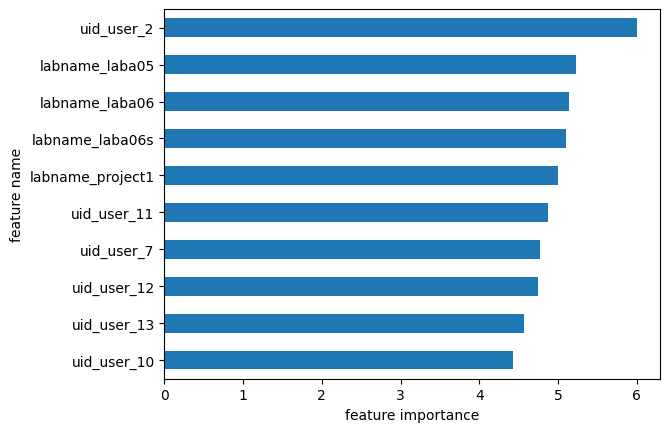

In [18]:
coef = np.array([est.coef_[0] for est in svc_clf.estimators_])
coef = calc_sum_coef(coef)
plot_feature_importances(coef=coef, feature_names=X.columns, top=10)

### c. Decision tree

In [19]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=21)
tree_clf.fit(X, y)
tree_accuracy = tree_clf.score(X, y)
tree_accuracy

0.5516014234875445

In [20]:
for max_depth in range(1, 26):
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=21)
    clf.fit(X, y)
    accuracy = clf.score(X, y)
    print(f"max_depth : {max_depth}, accuracy: {accuracy}")

max_depth : 1, accuracy: 0.35765124555160144
max_depth : 2, accuracy: 0.4389086595492289
max_depth : 3, accuracy: 0.48991696322657174
max_depth : 4, accuracy: 0.5516014234875445
max_depth : 5, accuracy: 0.6109134045077106
max_depth : 6, accuracy: 0.6637010676156584
max_depth : 7, accuracy: 0.7064056939501779
max_depth : 8, accuracy: 0.7502965599051008
max_depth : 9, accuracy: 0.7846975088967971
max_depth : 10, accuracy: 0.8196915776986952
max_depth : 11, accuracy: 0.8499406880189798
max_depth : 12, accuracy: 0.8831553973902728
max_depth : 13, accuracy: 0.9104389086595492
max_depth : 14, accuracy: 0.9317912218268091
max_depth : 15, accuracy: 0.9460260972716489
max_depth : 16, accuracy: 0.9608540925266904
max_depth : 17, accuracy: 0.9709371293001187
max_depth : 18, accuracy: 0.9798339264531435
max_depth : 19, accuracy: 0.9839857651245552
max_depth : 20, accuracy: 0.9869513641755635
max_depth : 21, accuracy: 0.9905100830367735
max_depth : 22, accuracy: 0.9922894424673784
max_depth : 23, a

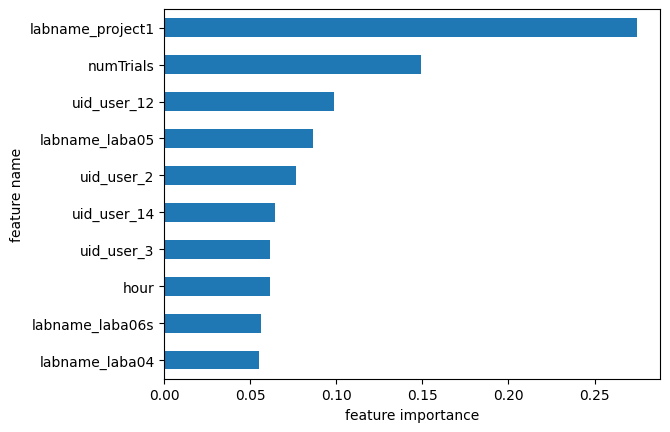

In [21]:
plot_feature_importances(coef=tree_clf.feature_importances_, feature_names=X.columns, top=10)

### d. Random forest

In [22]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf_clf.fit(X, y)
rf_accuracy = rf_clf.score(X, y)
rf_accuracy

1.0

In [23]:
for max_depth in [1, 4, 10, 20, 40]:
    print(f'max_depth : {max_depth}')
    for n_estimators in [1, 5, 10, 20, 50, 100]:
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=21)
        clf.fit(X, y)
        accuracy = clf.score(X, y)
        print(f'n_estimators: {n_estimators}, accuracy: {accuracy}')


max_depth : 1
n_estimators: 1, accuracy: 0.2508896797153025
n_estimators: 5, accuracy: 0.3499406880189798
n_estimators: 10, accuracy: 0.37129300118623965
n_estimators: 20, accuracy: 0.3879003558718861
n_estimators: 50, accuracy: 0.38730723606168443
n_estimators: 100, accuracy: 0.38730723606168443
max_depth : 4
n_estimators: 1, accuracy: 0.3932384341637011
n_estimators: 5, accuracy: 0.4928825622775801
n_estimators: 10, accuracy: 0.5225385527876631
n_estimators: 20, accuracy: 0.5587188612099644
n_estimators: 50, accuracy: 0.5432977461447213
n_estimators: 100, accuracy: 0.5219454329774614
max_depth : 10
n_estimators: 1, accuracy: 0.66785290628707
n_estimators: 5, accuracy: 0.8190984578884934
n_estimators: 10, accuracy: 0.8285883748517201
n_estimators: 20, accuracy: 0.891459074733096
n_estimators: 50, accuracy: 0.8701067615658363
n_estimators: 100, accuracy: 0.8855278766310795
max_depth : 20
n_estimators: 1, accuracy: 0.863582443653618
n_estimators: 5, accuracy: 0.9750889679715302
n_estima

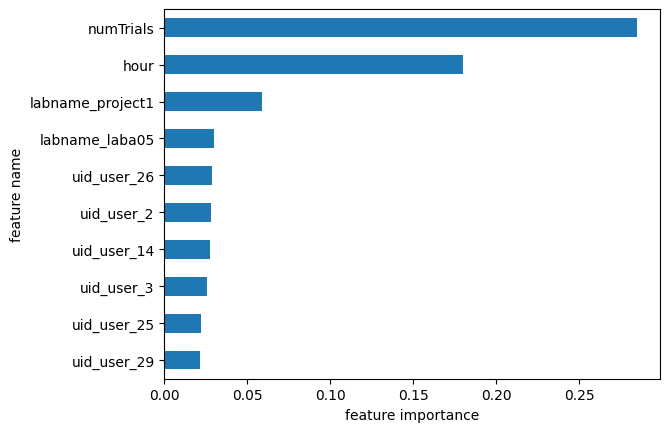

In [24]:
plot_feature_importances(coef=rf_clf.feature_importances_, feature_names=X.columns, top=10)